In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
plt.rcParams["figure.dpi"] = 140

In [3]:
class Lattice:
    def __init__(self, length=10, vacancy=1, seed=42):

        np.random.seed(seed)

        self.length = length
        self.vacancy = vacancy
        self.vacancyPos = []

        self.grid = np.ones((length, length))

        indices = np.random.choice(length * length, size=vacancy, replace=False)
        for idx in indices:
            x = idx // length
            y = idx % length
            self.grid[x, y] = 0
            self.vacancyPos.append((x, y))

    def PrintLattice(self):
        atoms = np.argwhere(self.grid == 1)
        vacancy = np.argwhere(self.grid == 0)

        if len(atoms) > 0:
            plt.scatter(atoms[:, 0], atoms[:, 1], c="blue", label="Atom")
        if len(vacancy) > 0:
            plt.scatter(vacancy[:, 0], vacancy[:, 1], c="red", label="Vacancy")
        plt.legend()
        plt.show()

    def RejectionKMC(self, Ea=2, iterations=1000, T=800, dt=1e-14):
        
        t = 0.0
        kb = 8.61e-5

        diffusion = []
        time = []
        msdList = []

        nu = 1e13
        jumpProb = min(1, nu * dt * np.exp(-Ea / (kb * T)))

        directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]

        x0, y0 = self.vacancyPos[0]
        unwrapX, unwrapY = x0, y0

        for _ in range(iterations):
            for i, (x, y) in enumerate(self.vacancyPos):
                idx = np.random.choice(len(directions))
                dx, dy = directions[idx]

                newX = (x + dx) % self.length
                newY = (y + dy) % self.length

                if np.random.rand() < jumpProb:
                    self.grid[x, y] = 1
                    self.grid[newX, newY] = 0

                    self.vacancyPos[i] = (newX, newY)

                    unwrapX += dx
                    unwrapY += dy

            totalDx = unwrapX - x0
            totalDy = unwrapY - y0
            t += dt
            msd = totalDx**2 + totalDy**2
            D = (msd / (4 * t)) * 1e-10
            diffusion.append(D)
            time.append(t)
            msdList.append(msd)

        plt.title("MSD vs Time (Rejection KMC)")
        plt.xlabel("Time")
        plt.ylabel("MSD")
        plt.grid()
        plt.plot(time, msdList)
        plt.show()

        plt.title("Diffusion vs Time (Rejection KMC)")
        plt.xlabel("Time")
        plt.ylabel("Diffusion")
        plt.grid()
        plt.plot(time, diffusion, c="red")
        plt.show()
        return D

    def RejectionFreeKMC(self, Ea=2, T=800, iterations=1000):
        kb = 8.61e-5
        nu = 1e13
        rate = nu * np.exp(-Ea / (kb * T))

        rates = np.array([rate, rate, rate, rate])

        R = np.sum(rates)
        P = rates / R
        cumSum = np.cumsum(P)

        t = 0.0
        time = []
        msdList = []
        diffusion = []

        x0, y0 = self.vacancyPos[0]
        unwrapX, unwrapY = x0, y0

        directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]

        for _ in range(iterations):
            for i, (x, y) in enumerate(self.vacancyPos):
                u = np.random.rand()
                idx = np.searchsorted(cumSum, u)  # Selects which direction to jump
                dx, dy = directions[idx]

                newX = (x + dx) % self.length
                newY = (y + dy) % self.length

                self.grid[x, y] = 1
                self.grid[newX, newY] = 0

                self.vacancyPos[i] = (newX, newY)
                unwrapX += dx
                unwrapY += dy

            u2 = np.random.rand()
            dt = -np.log(u2) / R
            t += dt

            time.append(t)
            totalDx = unwrapX - x0
            totalDy = unwrapY - y0
            msd = totalDx**2 + totalDy**2
            msdList.append(msd)

            D = (msd / (4 * t))*1e-10
            diffusion.append(D)

        plt.title("MSD vs Time (Rejection Free)")
        plt.xlabel("Time")
        plt.ylabel("MSD")
        plt.grid()
        plt.plot(time, msdList)
        plt.show()

        plt.title("Diffusion vs Time (Rejection Free)")
        plt.xlabel("Time")
        plt.ylabel("Diffusion")
        plt.grid()
        plt.plot(time, diffusion)
        plt.show()

        return D


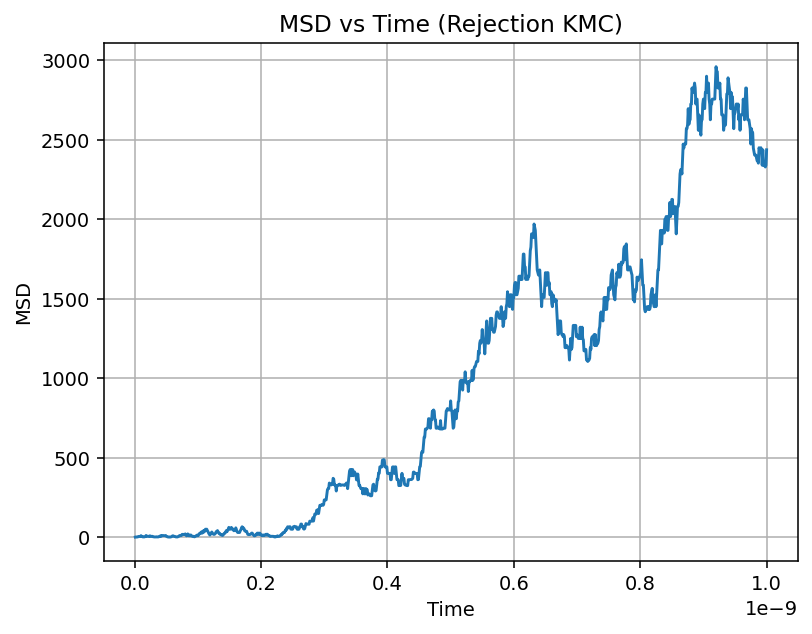

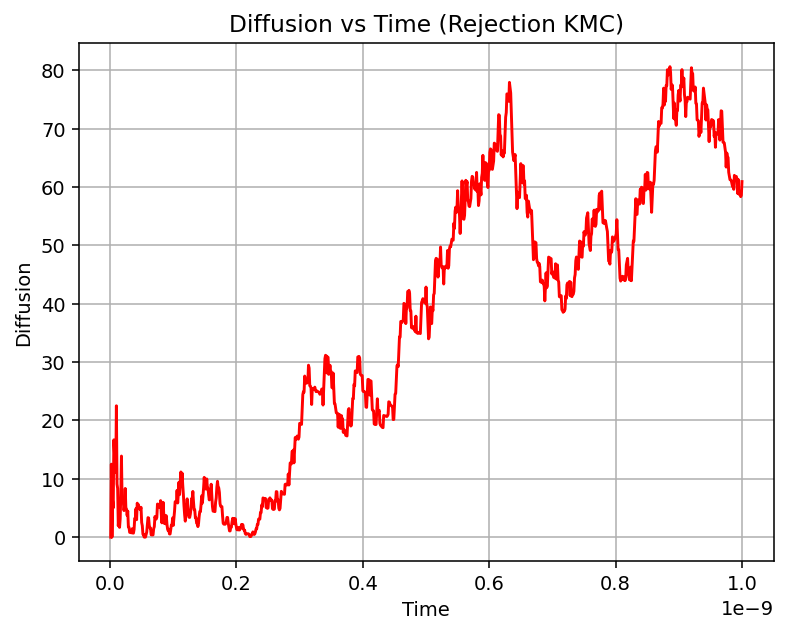

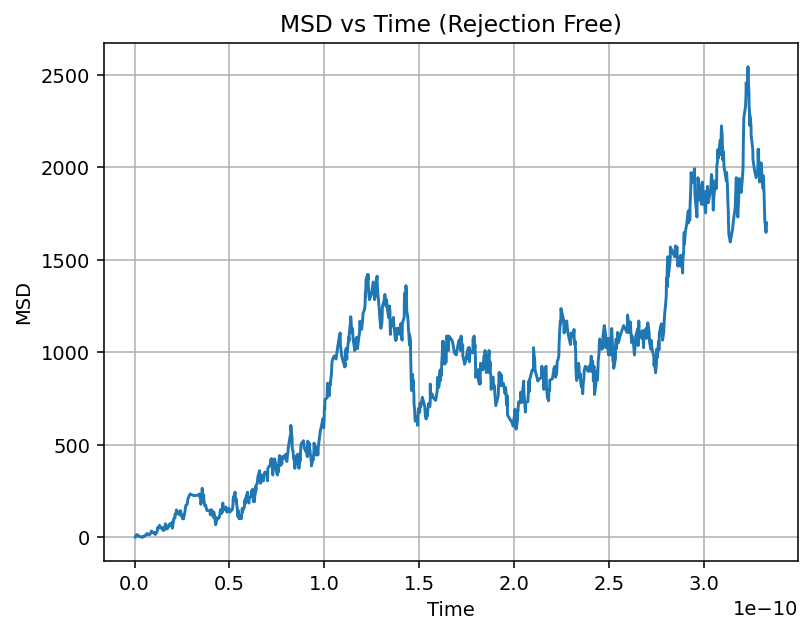

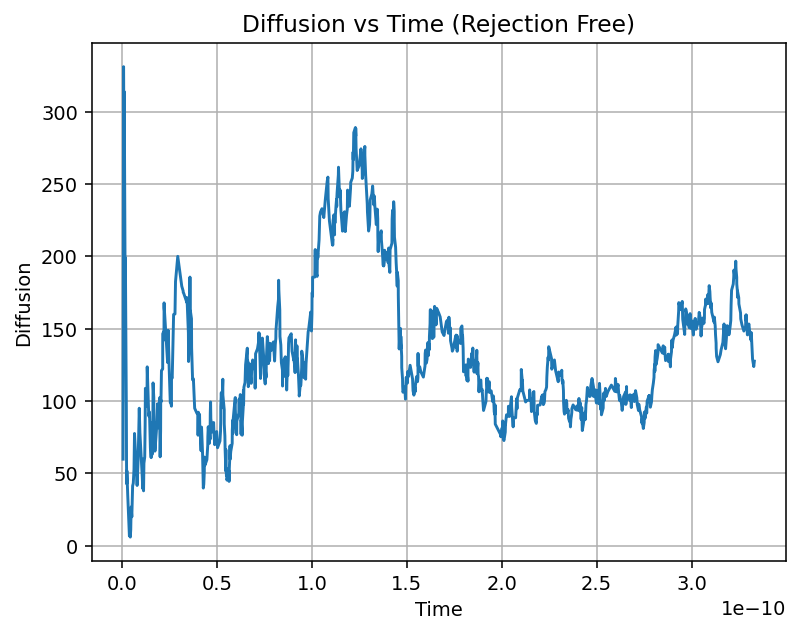

Rejection KMC:60.924999999999756
Rejection Free KMC: 127.58320325370738


In [5]:
iterations = 1000
Ea = 0.2
T = 900

rejectionlattice = Lattice(length=100)
rejectionFreeLattice = Lattice(length=100)

D1 = rejectionlattice.RejectionKMC(Ea,iterations,T,dt=1e-12)
D2 = rejectionFreeLattice.RejectionFreeKMC(Ea,T,iterations)

print(f"Rejection KMC:{D1}\nRejection Free KMC: {D2}")